# Week 8 Addendum — Expected Net Value vs. Decision Threshold

Regenerates the "expected net value vs. decision threshold" chart for the tuned
Gradient Boosting model, using the same pipeline as Week 5/6 (self-contained —
downloads the IBM Telco Customer Churn data via `kagglehub`, no manual CSV needed).

Two thresholds are marked on the plot for comparison:
- the **F1-optimal** threshold from Week 6 (0.36), chosen for ranking quality
- the **net-value-optimal** threshold found here, chosen for the Week 2 cost framework
  ($1,680 customer value, $50 intervention cost, 30% retention success rate)

These are different objectives and may or may not land on the same threshold —
the chart shows both rather than assuming they agree.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_predict
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Obtain the data (auto-download, same source as Week 5/6)

In [2]:
import kagglehub

path = kagglehub.dataset_download("yeanzc/telco-customer-churn-ibm-dataset")
df = pd.read_excel(os.path.join(path, "Telco_customer_churn.xlsx"))
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
print(df.shape)

100%|██████████| 1.25M/1.25M [00:04<00:00, 324kB/s]

Extracting files...


(7043, 33)


## Prepare the data — identical pipeline to Week 5/6

In [3]:
DROP_COLS = [
    "Count", "Country", "State",
    "CustomerID", "City", "Zip Code", "Lat Long", "Latitude", "Longitude",
    "Churn Label", "Churn Score", "Churn Reason", "CLTV",
    "Churn Value",
]
ADDON_COLS = ["Online Security", "Online Backup", "Device Protection",
              "Tech Support", "Streaming TV", "Streaming Movies"]
NUMERIC_FEATURES = ["Tenure Months", "Monthly Charges", "Total Charges", "Num_Addon_Services"]
PASSTHROUGH_FEATURES = ["AutoPay", "IsNewCustomer"]

def add_features(data):
    data = data.copy()
    data["Num_Addon_Services"] = (data[ADDON_COLS] == "Yes").sum(axis=1)
    data["AutoPay"] = data["Payment Method"].str.contains("automatic", case=False, na=False).astype(int)
    data["IsNewCustomer"] = (data["Tenure Months"] <= 6).astype(int)
    return data

def clean_data(data):
    data = data.copy()
    data["Total Charges"] = pd.to_numeric(data["Total Charges"], errors="coerce")
    data["Total Charges"] = data["Total Charges"].fillna(0)
    return data.drop(columns=DROP_COLS)

def make_Xy(data):
    return clean_data(add_features(data)), data["Churn Value"]

X_all, y_all = make_Xy(df)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE, stratify=y_all
)

categorical_features = [c for c in X_train_raw.columns
                         if c not in NUMERIC_FEATURES + PASSTHROUGH_FEATURES]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), NUMERIC_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False), categorical_features),
    ("bin", "passthrough", PASSTHROUGH_FEATURES),
])

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

print("X_train:", X_train.shape, " X_test:", X_test.shape)

X_train: (5634, 43)  X_test: (1409, 43)


## Re-tune Gradient Boosting — same search space as Week 6

Reproduces the tuned model so the threshold sweep is evaluated on the actual
final model, not a fresh untuned one.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

gb_dist = {
    "learning_rate": [0.03, 0.05, 0.1, 0.2],
    "max_leaf_nodes": [15, 31, 63],
    "max_depth": [None, 3, 6],
    "l2_regularization": [0.0, 0.1, 1.0],
    "max_iter": [150, 300],
    "min_samples_leaf": [20, 50],
}

rs_gb = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    gb_dist, n_iter=20, scoring="roc_auc", cv=cv, n_jobs=-1, random_state=RANDOM_STATE,
)
rs_gb.fit(X_train, y_train)
best_model = rs_gb.best_estimator_

print("GBoost best CV ROC-AUC:", round(rs_gb.best_score_, 4))
print("GBoost best params:", rs_gb.best_params_)

GBoost best CV ROC-AUC: 0.8637
GBoost best params: {'min_samples_leaf': 50, 'max_leaf_nodes': 31, 'max_iter': 150, 'max_depth': 3, 'learning_rate': 0.05, 'l2_regularization': 0.1}


## Out-of-fold probabilities (leakage-free, same method as Week 6's F1 threshold search)

In [5]:
oof_proba = cross_val_predict(best_model, X_train, y_train, cv=cv, method="predict_proba")[:, 1]

## Sweep thresholds — F1 (Week 6's criterion) and expected net value (Week 2's cost framework)

Cost framework: $1,680 customer value, $50 intervention cost, 30% retention success rate,
applied to each threshold's true positives and false positives on the out-of-fold predictions.

In [6]:
CUSTOMER_VALUE = 1680
INTERVENTION_COST = 50
SUCCESS_RATE = 0.30

def net_value(y_true, proba, threshold):
    pred = (proba >= threshold).astype(int)
    tp = int(((pred == 1) & (y_true == 1)).sum())
    fp = int(((pred == 1) & (y_true == 0)).sum())
    n = len(y_true)
    # scaled to a 1,000-customer population, matching the deck's "per 1,000 customers" framing
    scale = 1000 / n
    return (tp * SUCCESS_RATE * CUSTOMER_VALUE - (tp + fp) * INTERVENTION_COST) * scale

thresholds = np.linspace(0.05, 0.95, 91)
f1s = [f1_score(y_train, (oof_proba >= t).astype(int), zero_division=0) for t in thresholds]
net_values = [net_value(y_train, oof_proba, t) for t in thresholds]

f1_best_t = thresholds[int(np.argmax(f1s))]
nv_best_t = thresholds[int(np.argmax(net_values))]

print("F1-optimal threshold (out-of-fold):", round(f1_best_t, 3))
print("Net-value-optimal threshold (out-of-fold):", round(nv_best_t, 3))
print("Week 6 reported F1-optimal threshold: 0.36  <- compare against the value above")

F1-optimal threshold (out-of-fold): 0.32
Net-value-optimal threshold (out-of-fold): 0.08
Week 6 reported F1-optimal threshold: 0.36  <- compare against the value above


## Plot: expected net value vs. decision threshold

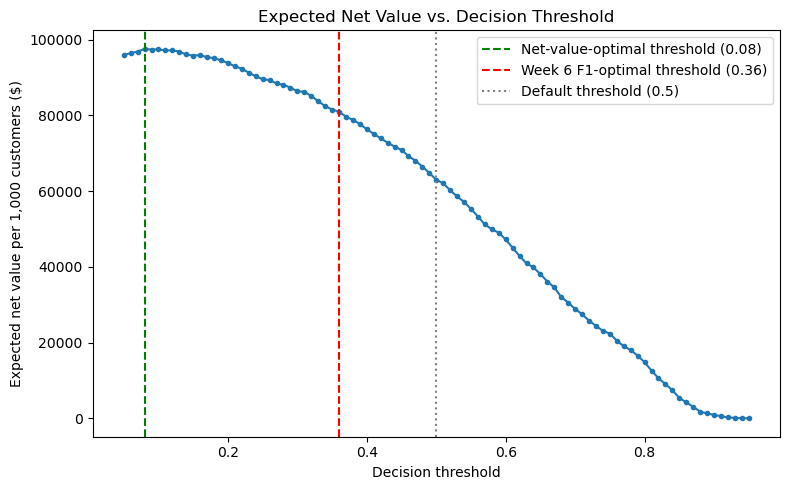

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, net_values, marker="o", markersize=3)
ax.axvline(nv_best_t, color="green", linestyle="--",
           label=f"Net-value-optimal threshold ({nv_best_t:.2f})")
ax.axvline(0.36, color="red", linestyle="--",
           label="Week 6 F1-optimal threshold (0.36)")
ax.axvline(0.5, color="gray", linestyle=":", label="Default threshold (0.5)")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Expected net value per 1,000 customers ($)")
ax.set_title("Expected Net Value vs. Decision Threshold")
ax.legend()
plt.tight_layout()
plt.savefig("net_value_vs_threshold.png", dpi=200, bbox_inches="tight")
plt.show()

## Cross-check against the test set

Confirms the net-value figures used on Slide 15 ($87,112 at the 0.5 default,
$112,126 at the 0.36 threshold) using the model fit on the full training set
and evaluated once on the held-out test set.

In [8]:
best_model_full = best_model  # already fit on X_train, y_train above
test_proba = best_model_full.predict_proba(X_test)[:, 1]

for t in [0.5, 0.36, nv_best_t]:
    pred = (test_proba >= t).astype(int)
    tp = int(((pred == 1) & (y_test == 1)).sum())
    fp = int(((pred == 1) & (y_test == 0)).sum())
    nv_test = tp * SUCCESS_RATE * CUSTOMER_VALUE - (tp + fp) * INTERVENTION_COST
    print(f"threshold={t:.2f}  precision={precision_score(y_test, pred):.3f}  "
          f"recall={recall_score(y_test, pred):.3f}  "
          f"net value on test set=${nv_test:,.0f}")

threshold=0.50  precision=0.667  recall=0.545  net value on test set=$87,516
threshold=0.36  precision=0.574  recall=0.719  net value on test set=$112,126
threshold=0.08  precision=0.402  recall=0.963  net value on test set=$136,690
